# Day 26 – Decision Tree (Customer Order Classification)
Dataset: Customer Purchase Behavior

Goal: Predict Order Status using Decision Tree and visualize the model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("/Users/aaronrao/Desktop/projects/Global Coding Challenge/day26/customer_dataset(in).csv")
df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,3/20/2024,Standard
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,4/20/2024,Overnight
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,10/17/2023,Express
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,8/9/2024,Overnight
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,5/21/2024,Express


In [3]:
df = df.drop(["Customer ID", "SKU", "Purchase Date"], axis=1)
df["Order Status"] = df["Order Status"].map({
    "Completed": 1,
    "Cancelled": 0
})

df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,Rating,Order Status,Total Price,Unit Price,Quantity,Gender_Male,Loyalty Member_Yes,Product Type_Laptop,Product Type_Smartphone,...,Product Type_Tablet,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Paypal,Shipping Type_Express,Shipping Type_Overnight,Shipping Type_Same Day,Shipping Type_Standard
0,53,2,0,5538.33,791.19,7,True,False,False,True,...,False,False,True,False,False,False,False,False,False,True
1,53,3,1,741.09,247.03,3,True,False,False,False,...,True,False,False,False,False,True,False,True,False,False
2,41,3,1,1855.84,463.96,4,True,False,True,False,...,False,False,True,False,False,False,True,False,False,False
3,41,2,1,3164.76,791.19,4,True,True,False,True,...,False,True,False,False,False,False,False,True,False,False
4,75,5,1,41.50,20.75,2,True,True,False,True,...,False,True,False,False,False,False,True,False,False,False


In [4]:
X = df.drop("Order Status", axis=1)
y = df["Order Status"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model = DecisionTreeClassifier(max_depth=3)  
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [7]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.67025


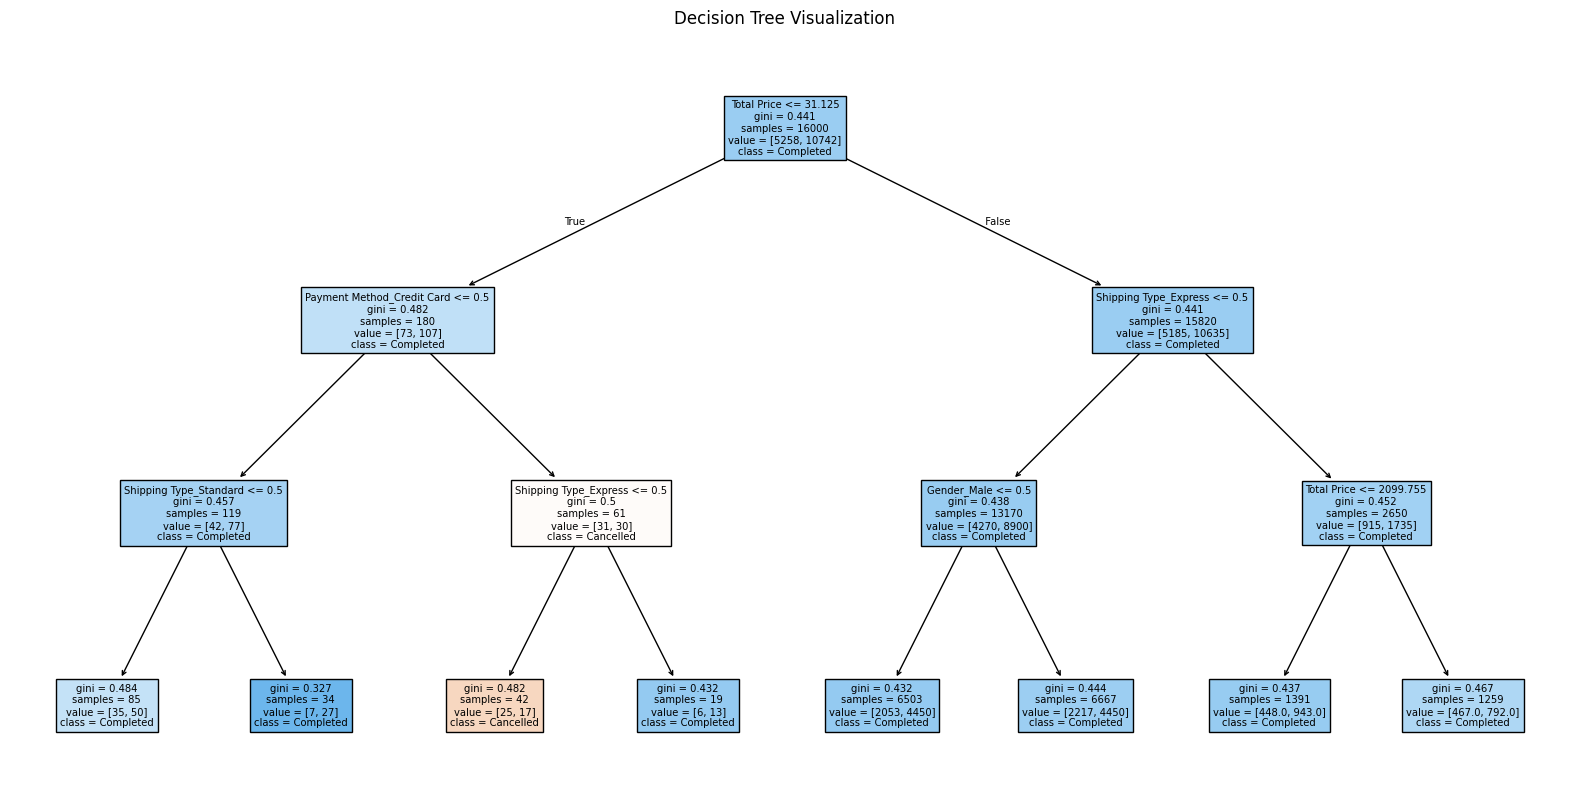

In [8]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Cancelled", "Completed"],
    filled=True
)

plt.title("Decision Tree Visualization")
plt.show()

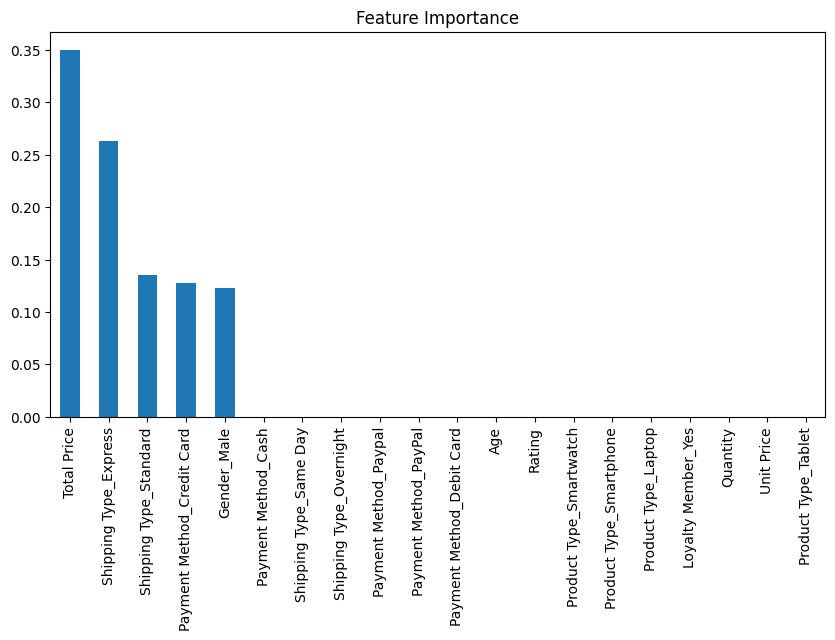

In [9]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))

plt.title("Feature Importance")
plt.show()

## Key Insights

1. Decision Tree splits data based on feature thresholds.
2. Important features influencing order status were identified.
3. Tree visualization shows clear decision paths.
4. Model performance depends on tree depth.
5. Decision Trees are highly interpretable compared to other models.